# Libraries

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import numpy as np

## Possible Rarities and its order

In [2]:
# Rarity Order for sorting
# Higher value means rarer card
rarityOrder = {
    "Common": 10,
    "Uncommon": 20,
    "Rare": 30,                         # Regular
    "Classic Collection": 31,
    "Rare Holo": 40,                    # Holofoil
    "Double Rare": 50,                  # EX
    "Ultra Rare": 60,                   # Unique card classification
    "Rare Ultra": 60,                   # Unique card classification
    "Rare Holo Star": 61,
    "Rare Prime": 61,
    "Rare Holo LV.X": 61,
    "Rare Holo EX": 61,
    "Rare Holo GX": 61,
    "LEGEND": 61,
    "Rare BREAK": 61,
    "Amazing Rare": 61,
    "Rare Prism Star": 61,
    "Rare ACE": 61,
    "ACE SPEC Rare": 61,
    "Radiant Rare": 62,
    "Rare Holo V": 63,
    "Rare Holo VSTAR": 64,
    "Rare Holo VMAX": 65,
    "Trainer Gallery Rare Holo": 66,
    "Rare Secret": 70,                  # Out of numbers
    "Rare Shining": 71,                 # Shiny Pokemon
    "Shiny Rare": 72,                   # Shiny Pokemon
    "Rare Shiny": 72,                   # Shiny Pokemon
    "Rare Shiny GX": 73,                # Shiny Pokemon
    "Shiny Ultra Rare": 73,             # Shiny Pokemon
    "Rare Rainbow": 74,
    "Illustration Rare": 75,            # Full-Art
    "Special Illustration Rare": 76,    # Full-Art
    "Hyper Rare": 80,                   # Gold Cards
    "Promo": 90                         # Event Cards
}

replace_dict = {1:1, 2:2, 3:3, 5:4, 7:5, 10:6, 21:7, 23:8, 25:9, 31:10}

# List of grade order
# Number has no meaning
gradeOrder = {
    'holo-nearmint': 1,
    'holo-good': 2,
    'holo-played': 3,
    'holo-used' : 4, 
    'holo-poor': 5,
    'reverse-nearmint': 6,
    'reverse-good': 7,
    'reverse-played': 8,
    'reverse-used': 9,
    'reverse-poor': 10,
    'normal-nearmint': 11,
    'normal-good': 12,
    'normal-played': 13,
    'normal-used': 14,
    'normal-poor': 15
}

# Dataframe

In [3]:
# Read data
df = pd.read_csv('merged_pokemon_data.csv')

# Process Data
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df['Month'] = df['Month'].dt.strftime('%Y-%m')
df = df.sort_values('Month')

df['Average'] = pd.to_numeric(df['Average'], errors='coerce')

# Sort the unique rarities in the DataFrame using rarityOrder
sorted_rarities = sorted(df['Rarity'].dropna().unique(), key=lambda r: rarityOrder.get(r, float('inf')), reverse=True)
sorted_grades = sorted(df['Grade'].dropna().unique(), key=lambda r: gradeOrder.get(r, float('inf')), reverse=False)

In [56]:
print(df.sort_values(by='Average', ascending=False))

      Set ID  Number          Name        Rarity            Grade    Month  \
34444  swsh5     155   Tyranitar V    Rare Ultra    holo-nearmint  2024-05   
34445  swsh5     155   Tyranitar V    Rare Ultra    holo-nearmint  2024-06   
28024  swsh4     188  Pikachu VMAX  Rare Rainbow        holo-good  2023-03   
34439  swsh5     155   Tyranitar V    Rare Ultra        holo-good  2024-05   
28023  swsh4     188  Pikachu VMAX  Rare Rainbow        holo-good  2023-02   
...      ...     ...           ...           ...              ...      ...   
22448  swsh3      58     Electrike        Common      normal-good  2023-07   
27039  swsh4     159  Rocky Helmet      Uncommon    normal-played  2024-08   
25396  swsh4     123     Ferroseed        Common      normal-good  2023-02   
26688  swsh4     151   Drone Rotom      Uncommon  normal-nearmint  2024-05   
3022   swsh1     165           Hop      Uncommon    normal-played  2024-08   

        Average  rarity_rank  
34444  18767.00            7  
3

# Heatmaps

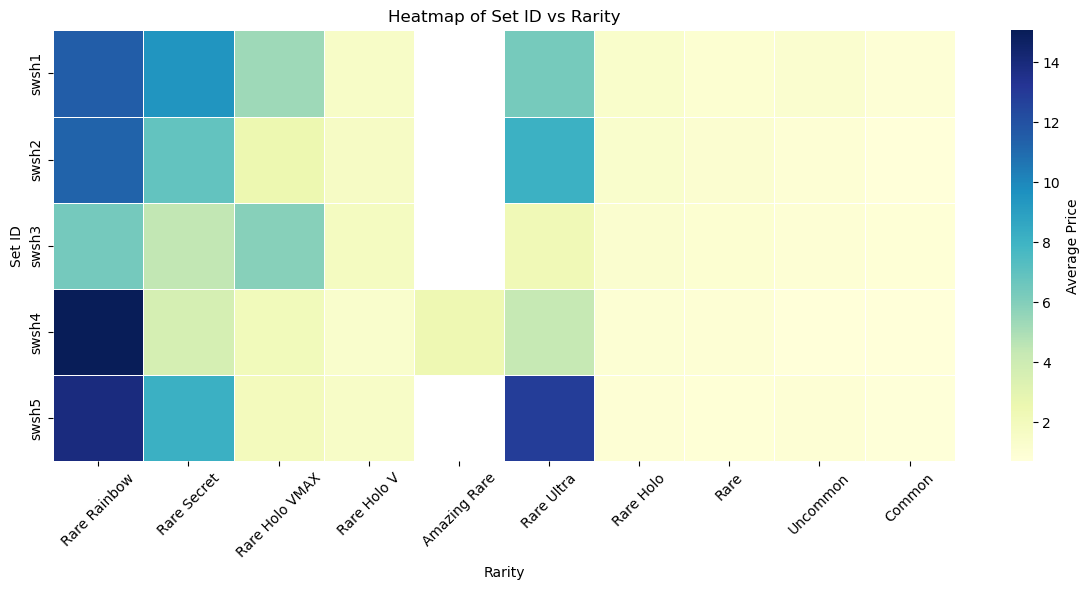

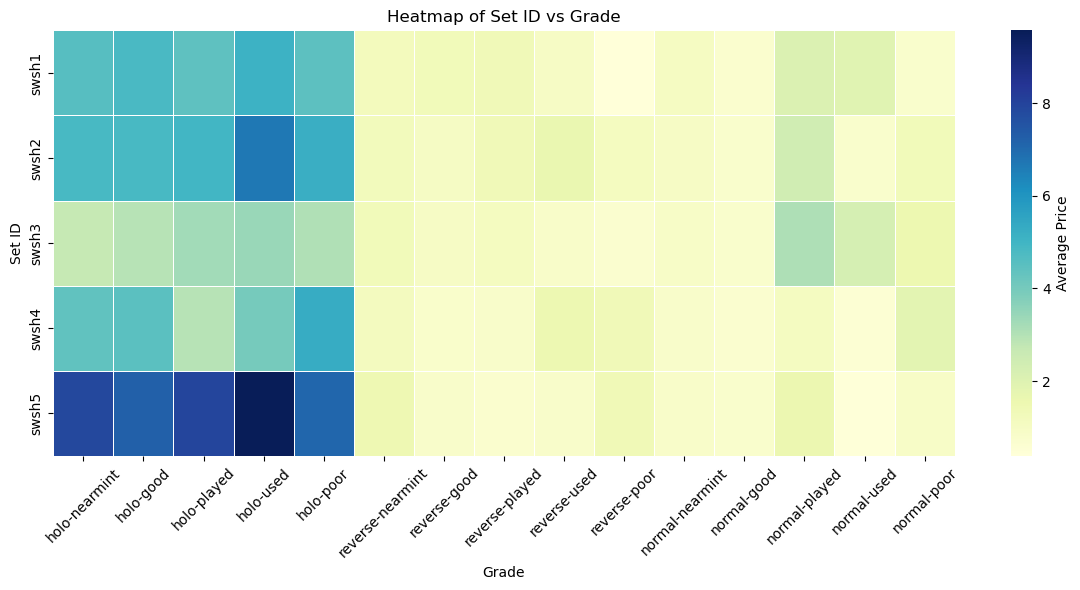

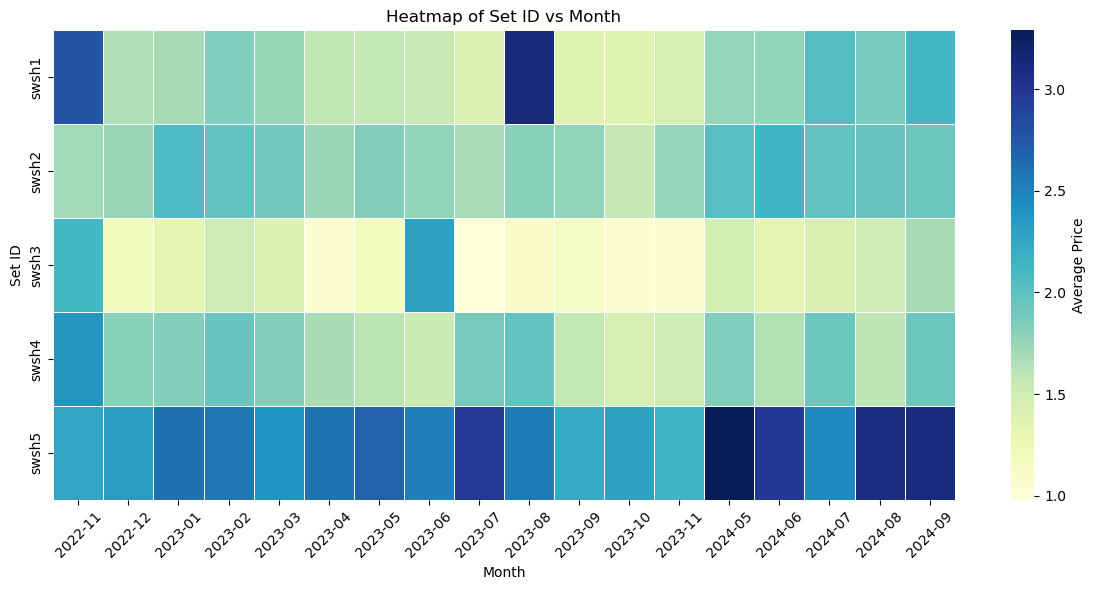

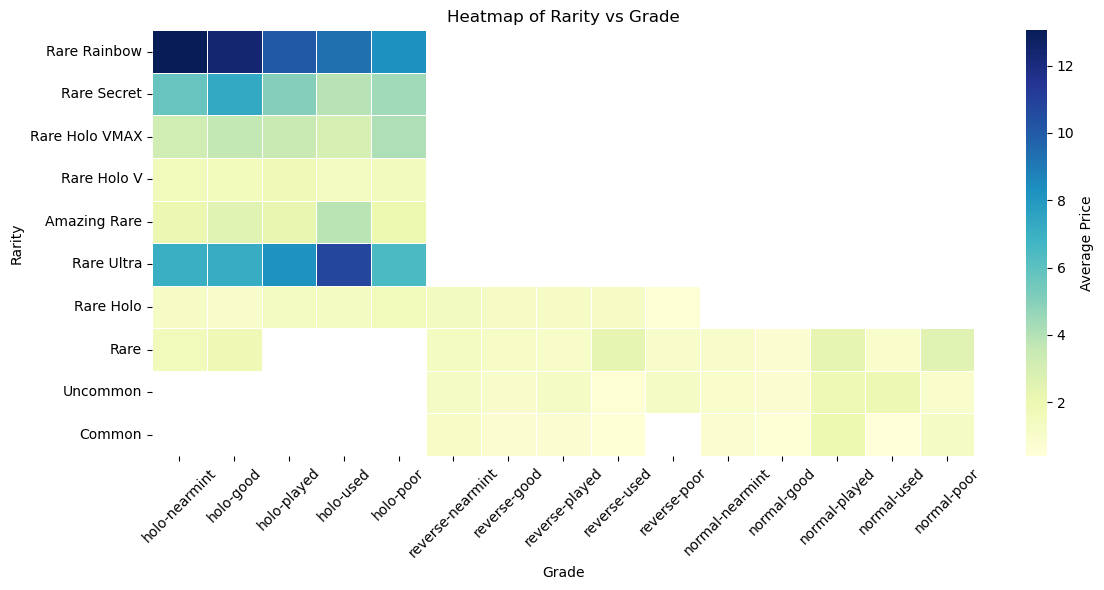

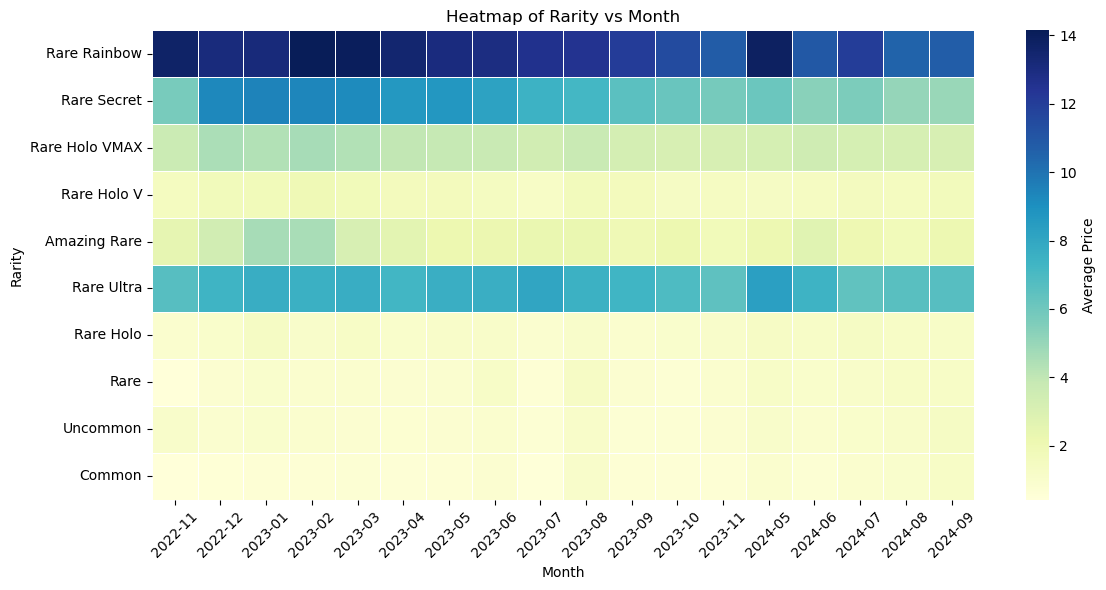

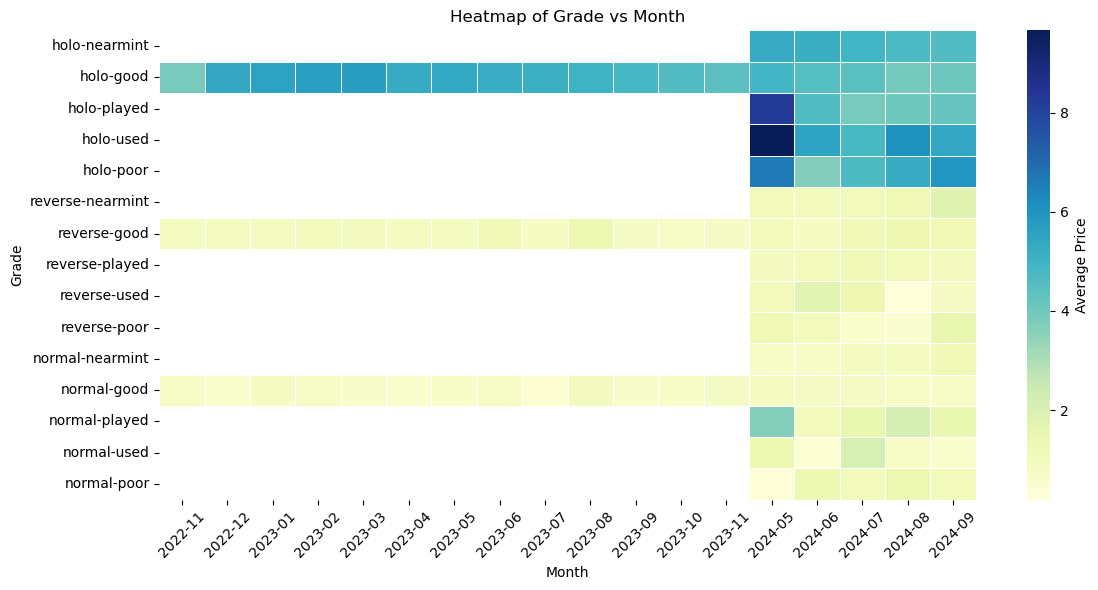

In [4]:
# List of heatmap pairs
heatmap_combos = [
    ('Set ID', 'Rarity'),
    ('Set ID', 'Grade'),
    ('Set ID', 'Month'),
    ('Rarity', 'Grade'),
    ('Rarity', 'Month'),
    ('Grade', 'Month'),
]

for row_attr, col_attr in heatmap_combos:
    pivot_table = df.pivot_table(index=row_attr, columns=col_attr, values='Average', aggfunc='mean')
    pivot_table = pivot_table.div(100).round(2)

    # Sort based on Rarity if it's in the rows or columns
    if row_attr == 'Rarity':
        pivot_table = pivot_table.loc[sorted_rarities]
    if col_attr == 'Rarity':
        pivot_table = pivot_table[sorted_rarities]

    # Sort based on Grade if it's in the rows or columns
    if row_attr == 'Grade':
        pivot_table = pivot_table.loc[sorted_grades]
    if col_attr == 'Grade':
        pivot_table = pivot_table[sorted_grades]

    # Plot
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, annot=False, cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Average Price'})
    plt.title(f'Heatmap of {row_attr} vs {col_attr}')
    plt.ylabel(row_attr)
    plt.xlabel(col_attr)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Scatterplots

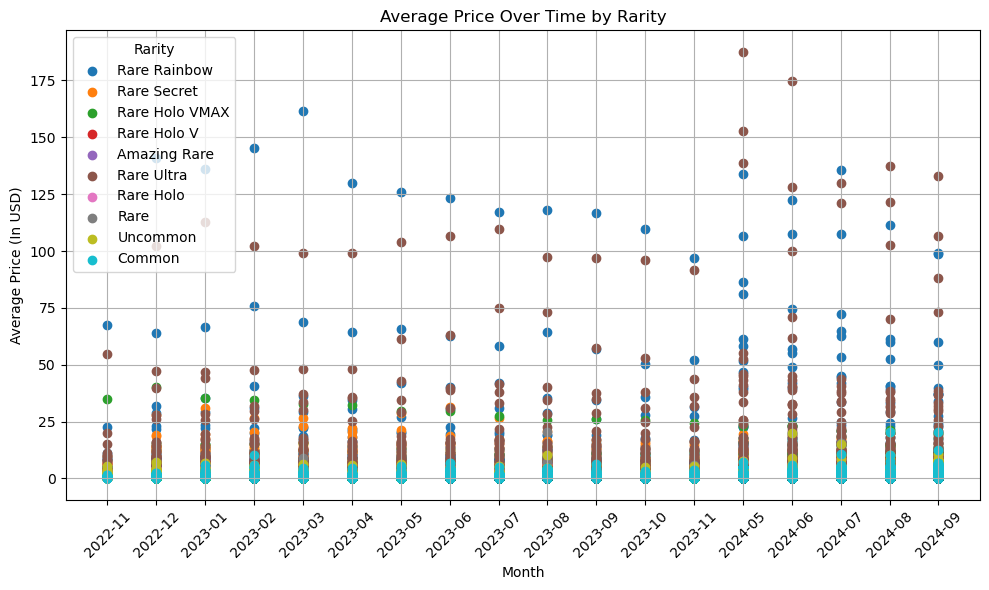

In [5]:
# Process Data
plt.figure(figsize=(10, 6))
dfs_by_rarity = []
for rarity in sorted_rarities:
    subset = df[df['Rarity'] == rarity]
    dfs_by_rarity.append(subset)
    plt.scatter(subset['Month'], subset['Average'].div(100).round(2), label=rarity, marker='o')

# Set graph title and labels
plt.title('Average Price Over Time by Rarity')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.legend(title='Rarity')
plt.grid(True)
plt.tight_layout()

plt.show()


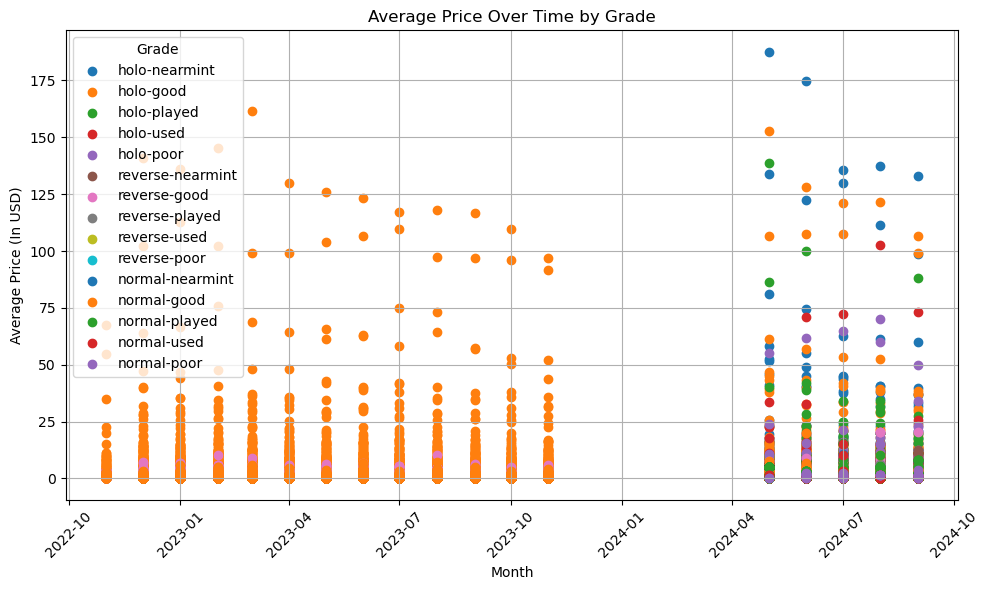

In [6]:
# Load and prepare data
df_sub = pd.read_csv('merged_pokemon_data.csv')
df_sub['Month'] = pd.to_datetime(df_sub['Month'], errors='coerce')
df_sub = df_sub.sort_values('Month')

# Process Data
plt.figure(figsize=(10, 6))
dfs_by_grade = []

for grade in sorted_grades:
    subset = df_sub[df_sub['Grade'] == grade]
    dfs_by_grade.append(subset)
    plt.scatter(subset['Month'], subset['Average'].div(100).round(2), label=grade, marker='o')

# Plot
plt.title('Average Price Over Time by Grade')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.legend(title='Grade')
plt.grid(True)
plt.tight_layout()

# Format x-axis as "YYYY-MM"
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

plt.show()


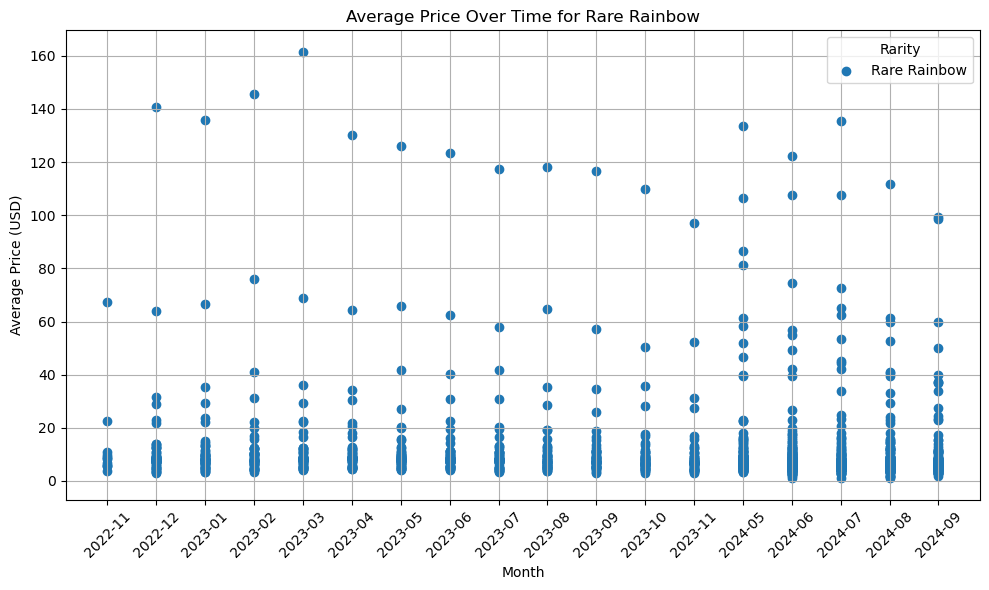

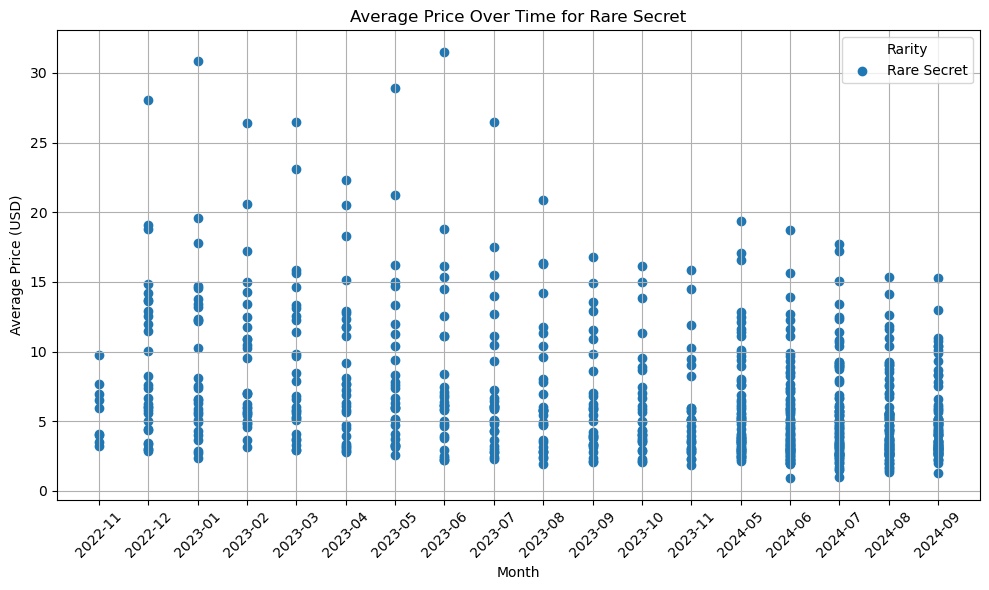

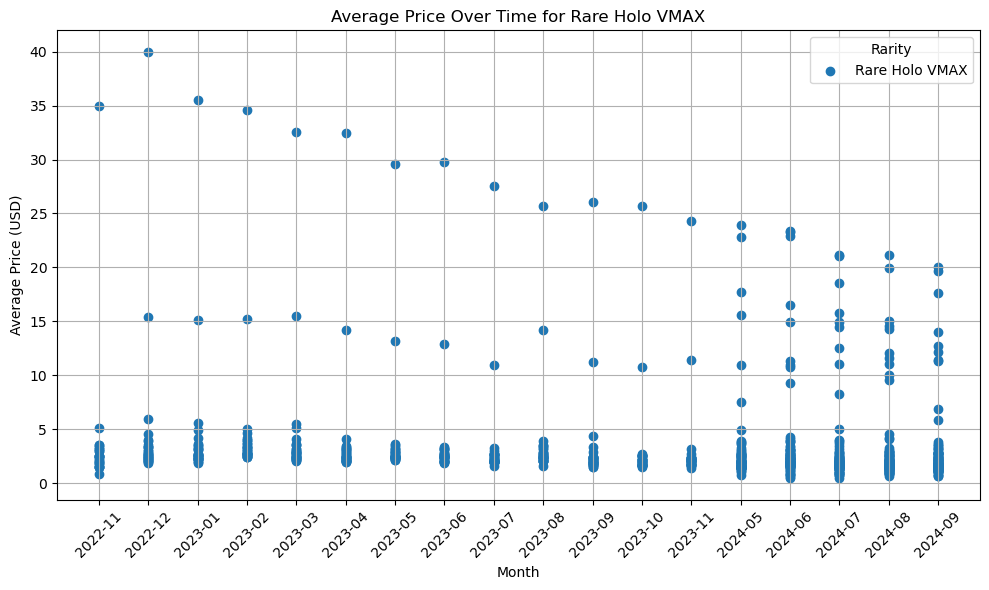

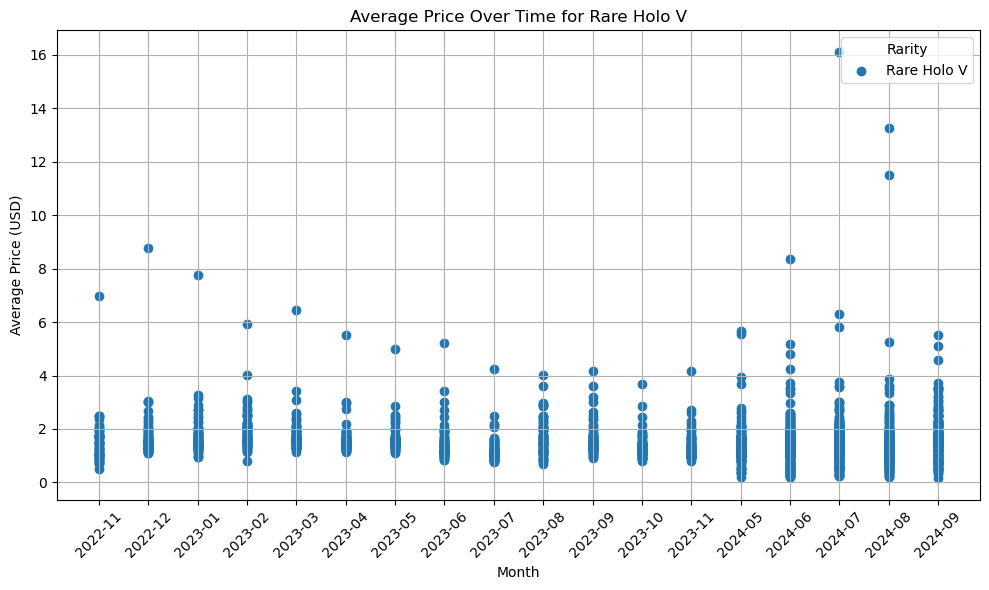

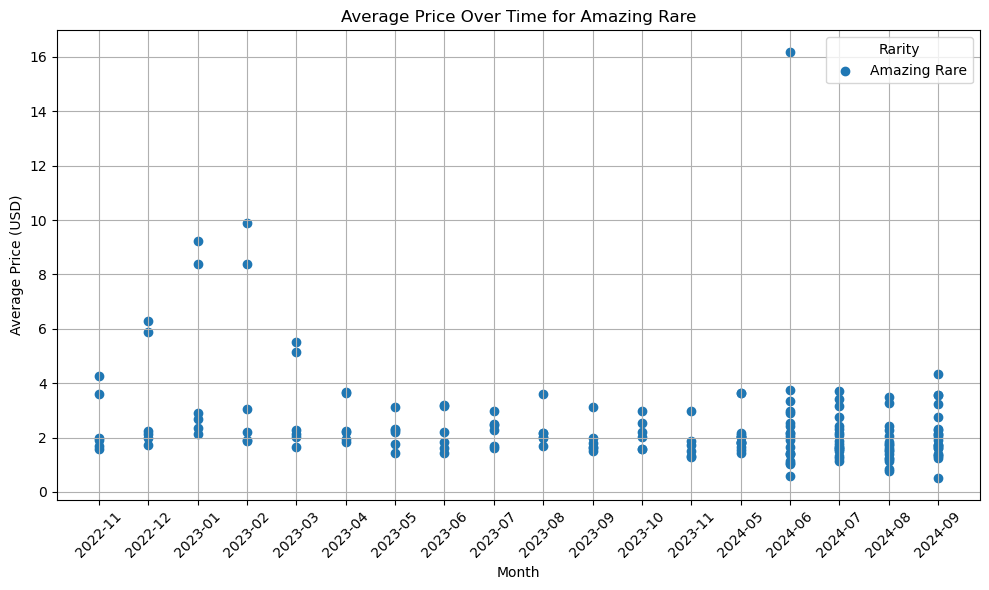

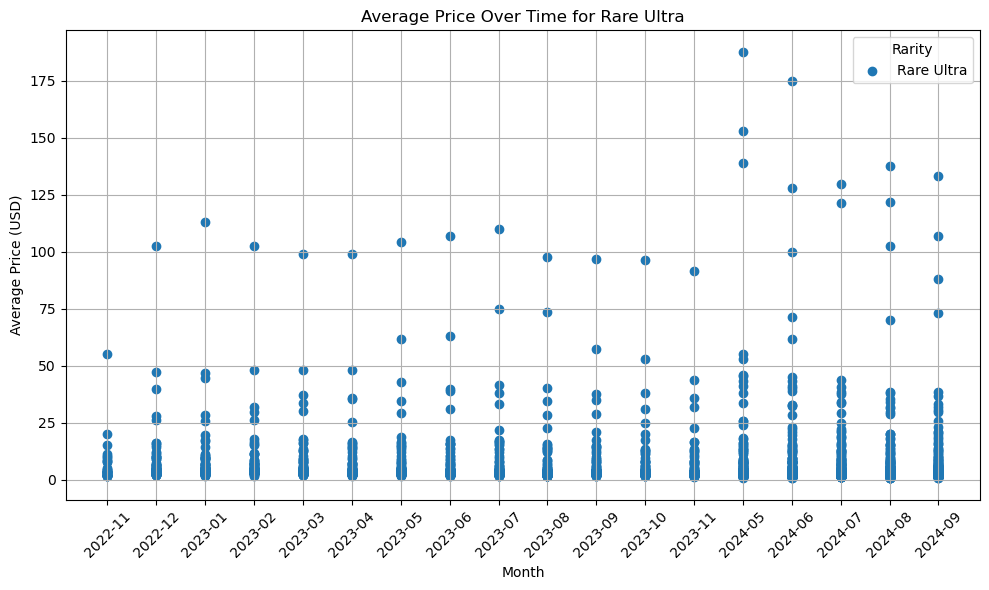

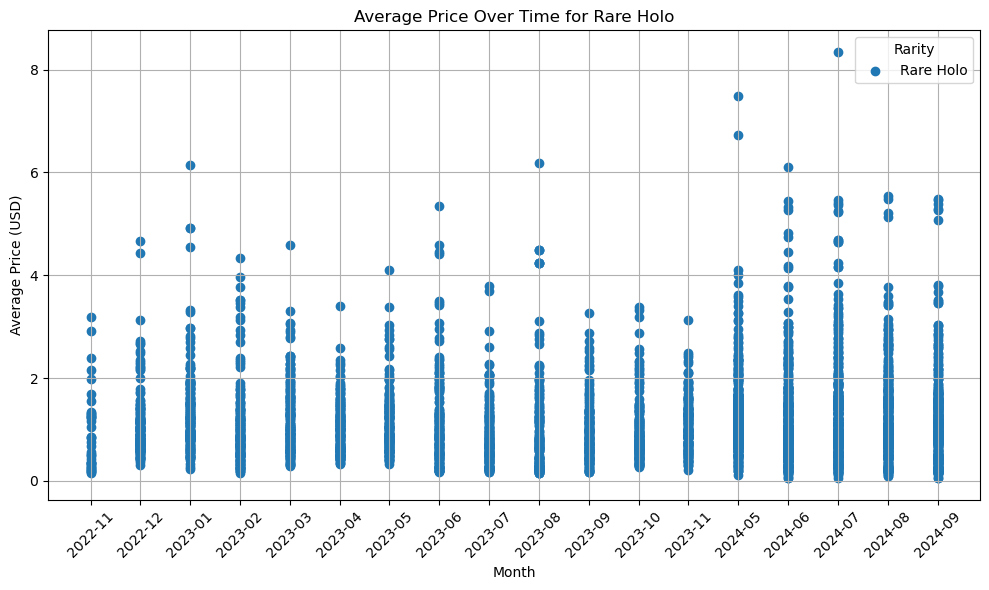

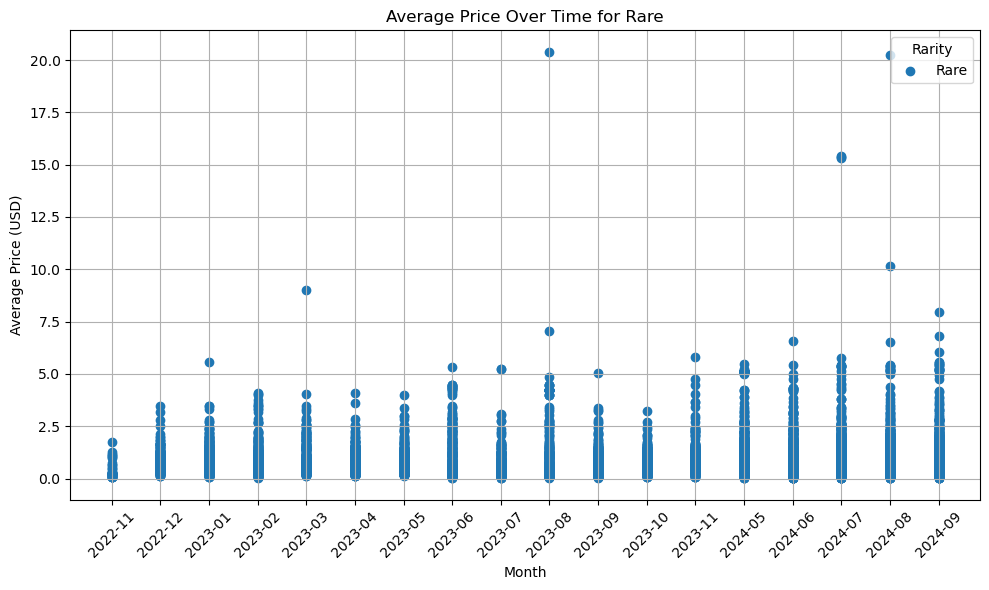

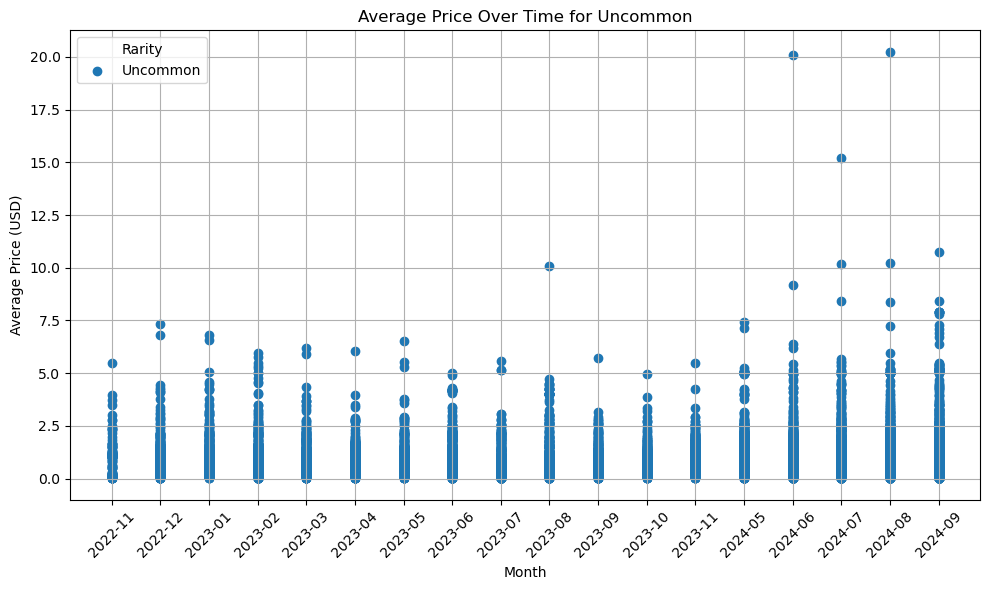

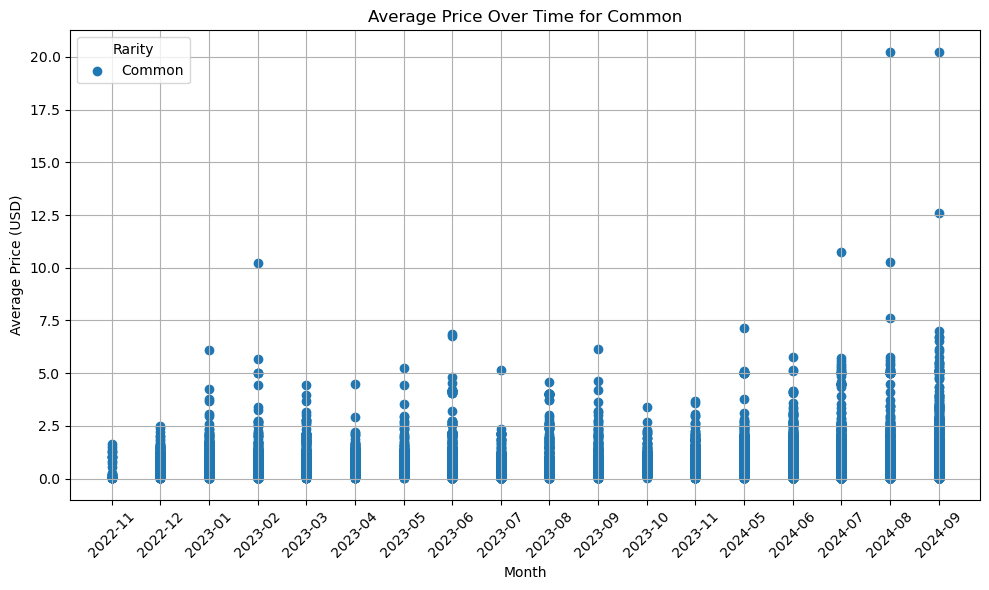

In [7]:
# Loop over each Rarity
for rarity in sorted_rarities:
    # Filter data for the current rarity
    subset = df[df['Rarity'] == rarity].sort_values(by='Month')
    
    # Create a new figure
    plt.figure(figsize=(10, 6))
    
    # Plot scatter plot
    plt.scatter(
        subset['Month'],
        subset['Average'] / 100,  # Convert cents to dollars
        label=rarity,
        marker='o'
    )
    
    # Plot
    plt.title(f'Average Price Over Time for {rarity}')
    plt.xlabel('Month')
    plt.ylabel('Average Price (USD)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title='Rarity')
    plt.tight_layout()
    plt.show()


# Boxplots

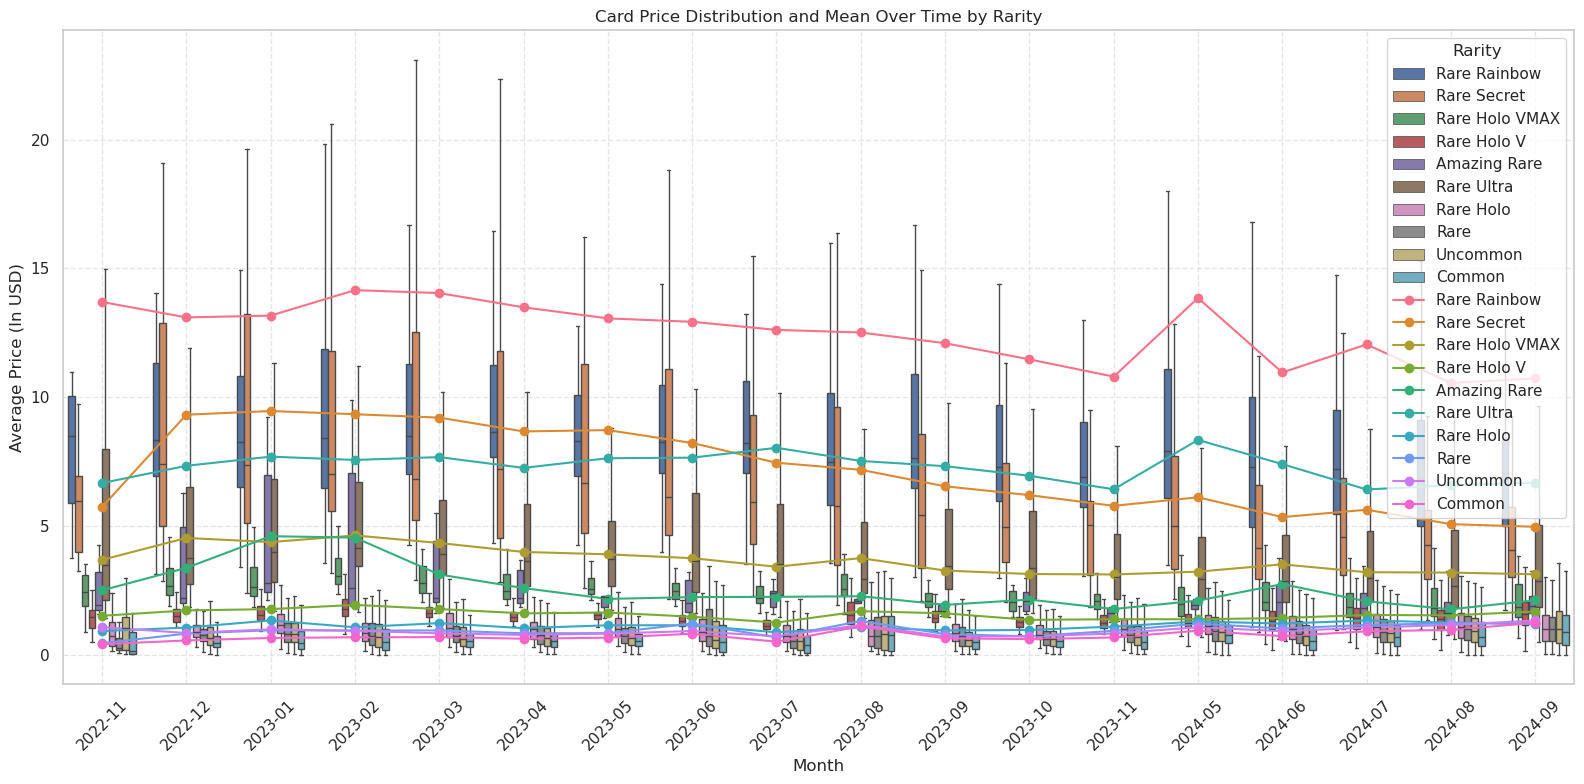

In [8]:
# Set style
sns.set(style='whitegrid')

plt.figure(figsize=(16, 8))

# Boxplot (all data combined)
sns.boxplot(
    data=df, 
    x=df['Month'] , 
    y=df['Average'] / 100, 
    hue='Rarity', 
    hue_order=sorted_rarities,
    showfliers=False,
    dodge=True, 
    linewidth=1
)

# Mean line per rarity
palette = sns.color_palette("husl", len(sorted_rarities))
for rarity, color in zip(sorted_rarities, palette):
    subset = df[df['Rarity'] == rarity]
    mean_per_month = subset.groupby('Month')['Average'].mean() / 100
    plt.plot(mean_per_month.index, mean_per_month.values, label=rarity, color=color, marker='o')

# Customize plot
plt.title('Card Price Distribution and Mean Over Time by Rarity')
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.xticks(rotation=45)
plt.legend(title='Rarity')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


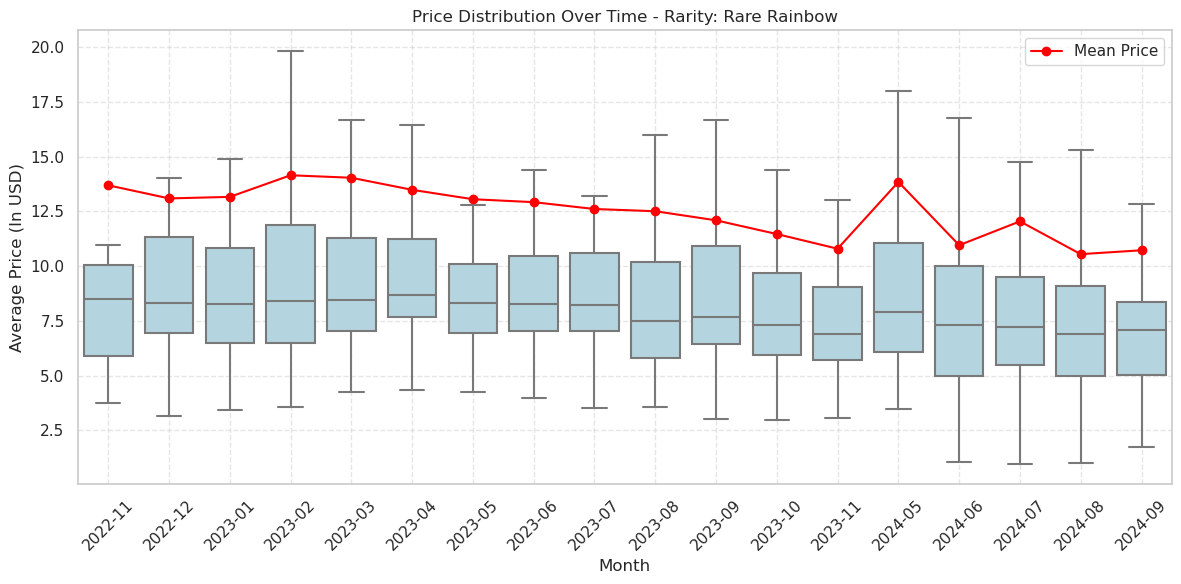

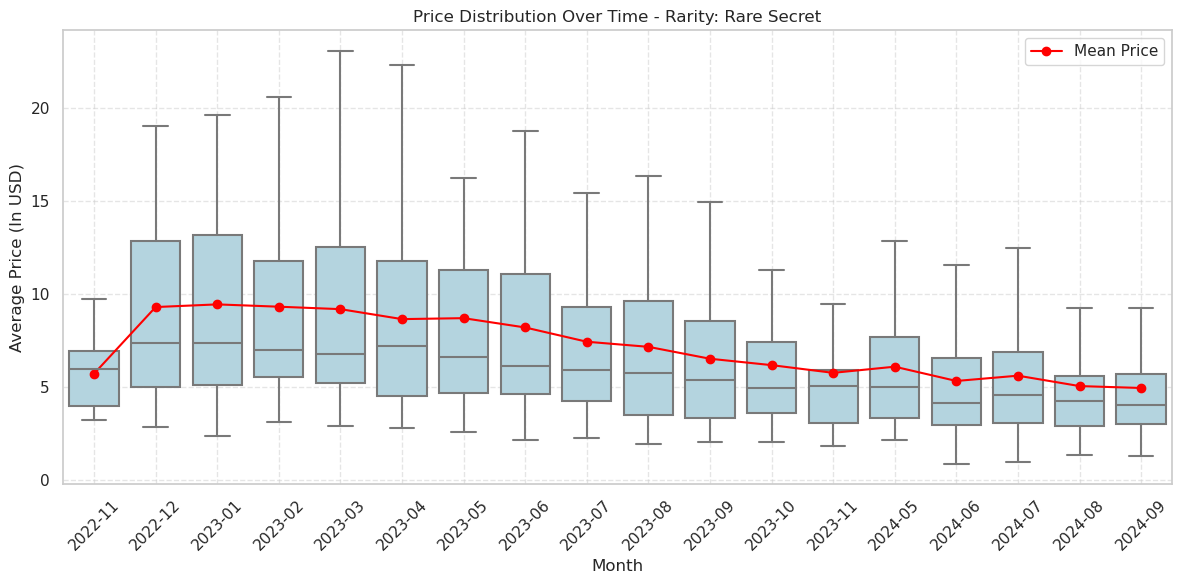

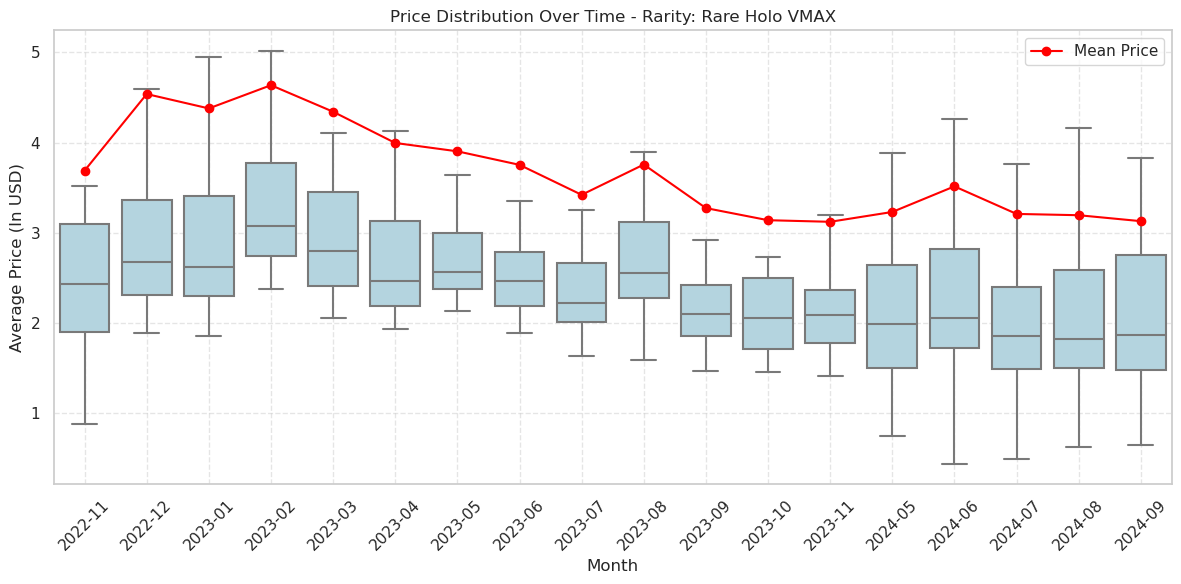

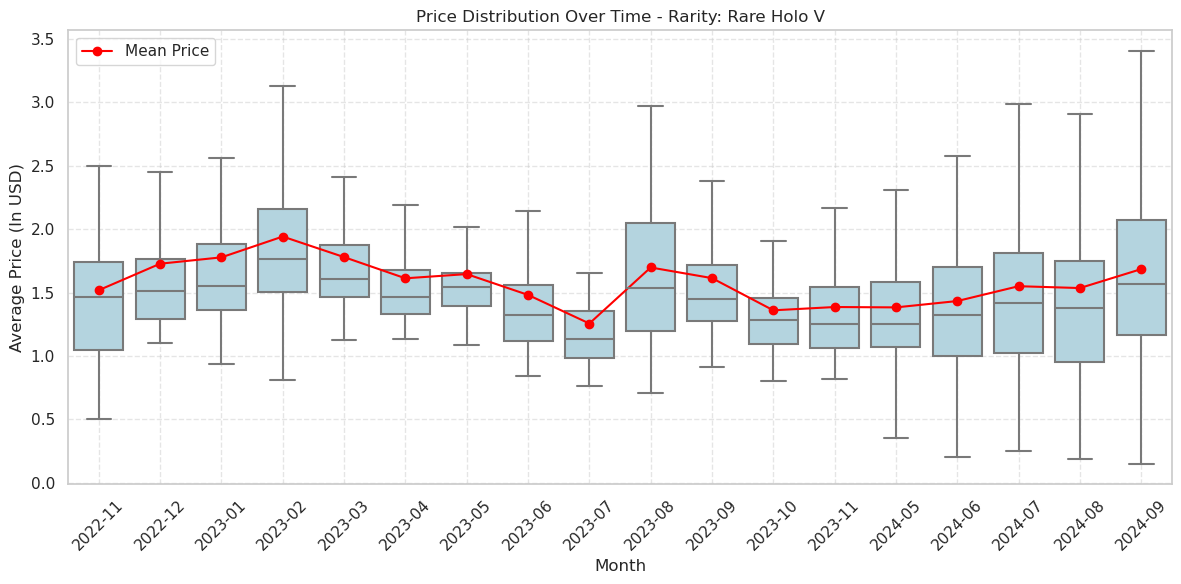

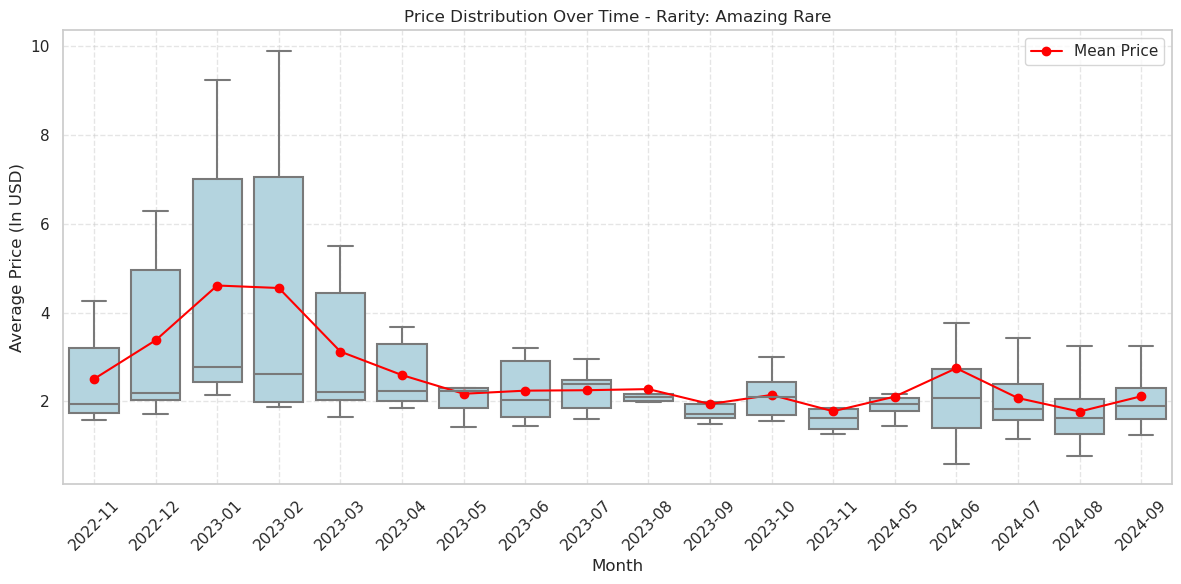

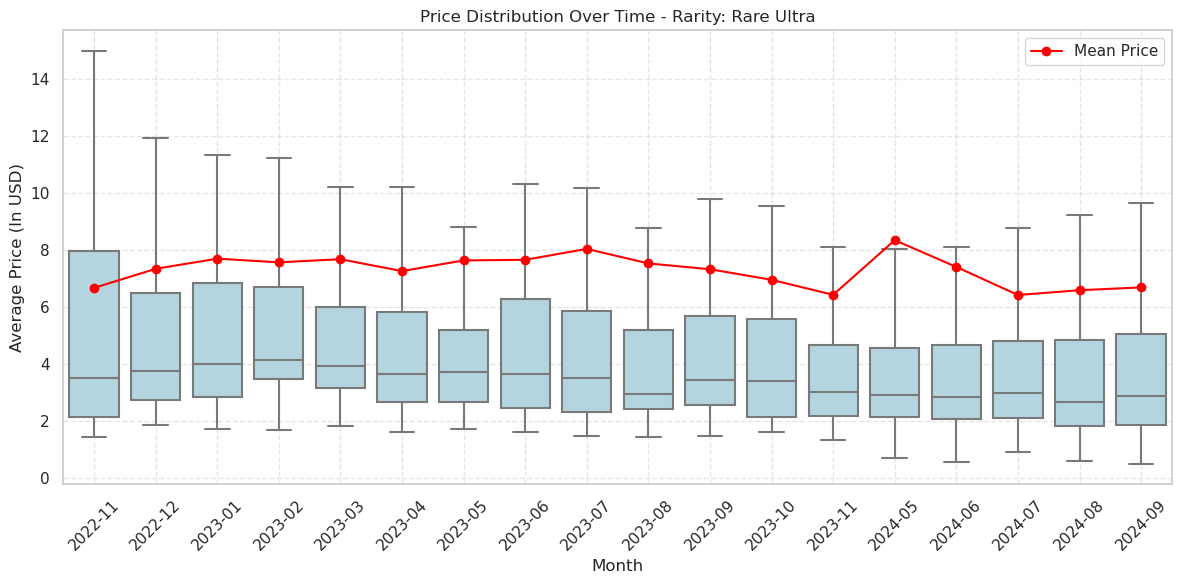

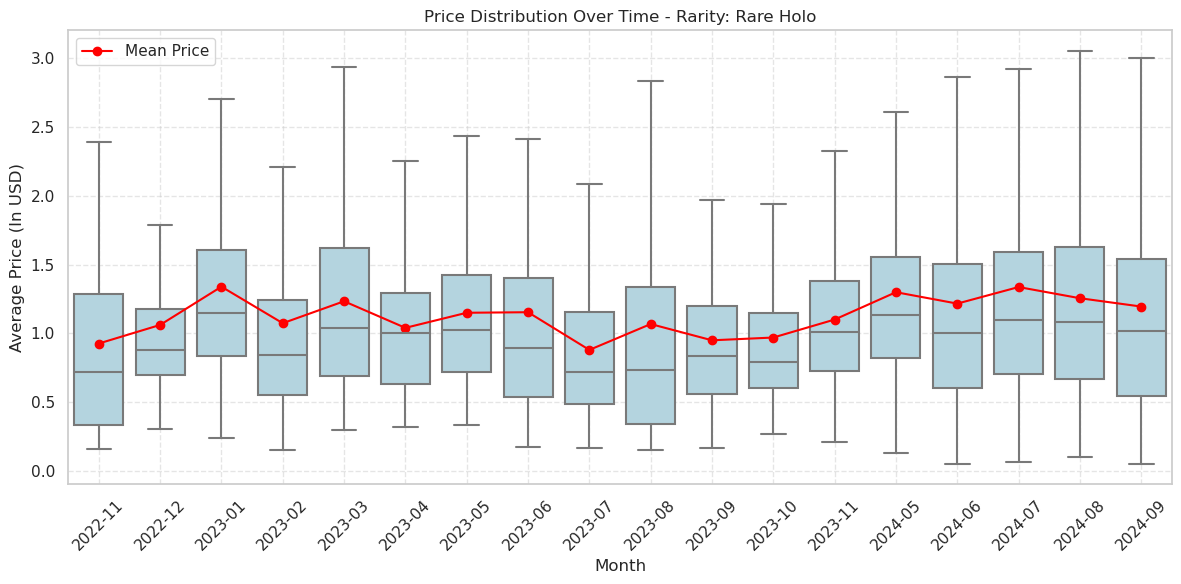

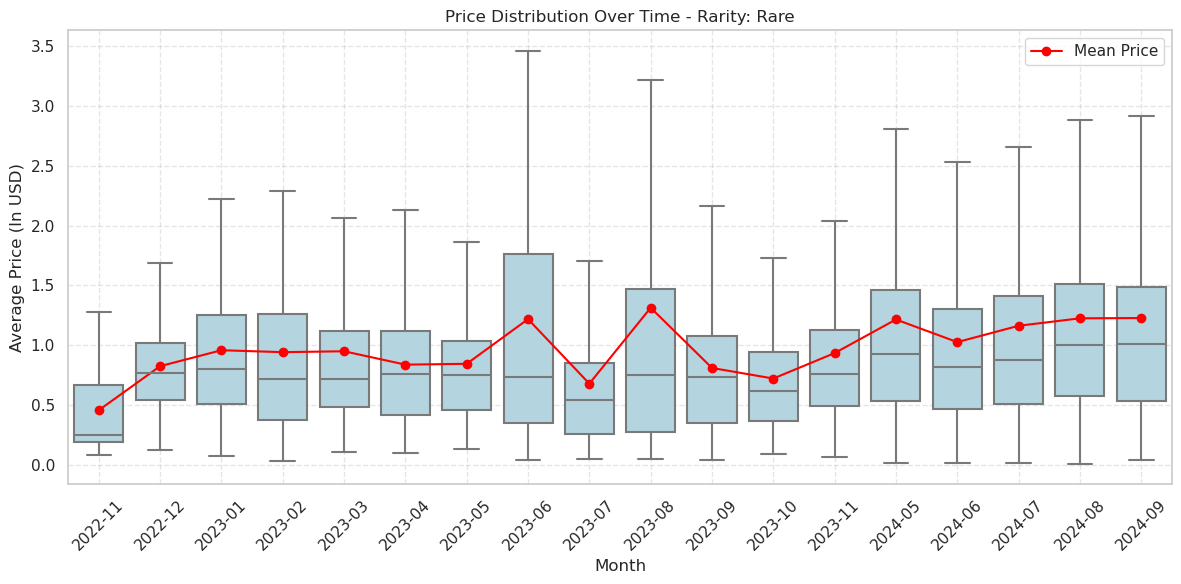

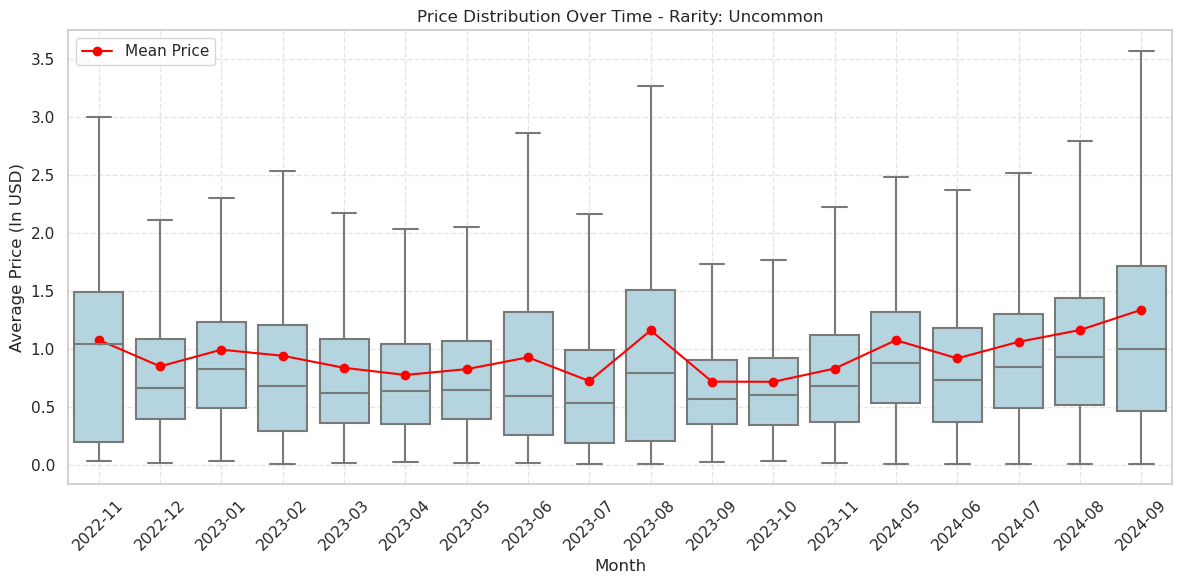

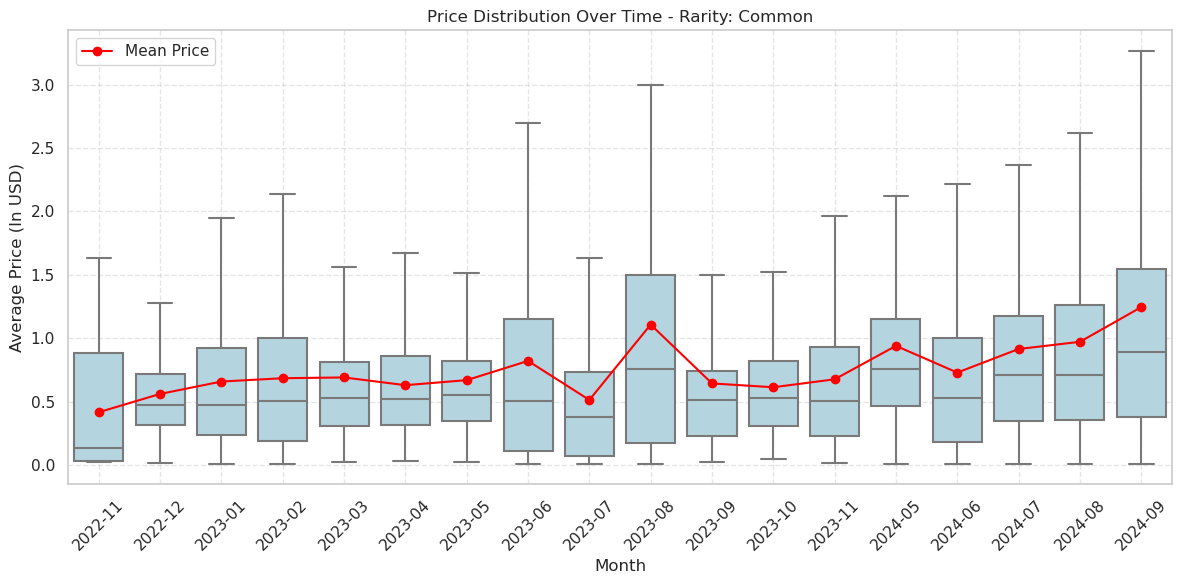

In [9]:
# Graph Style
sns.set(style='whitegrid')

# Plot for each rarity
for rarity in sorted_rarities:
    subset = df[df['Rarity'] == rarity]

    plt.figure(figsize=(12, 6))
    
    # Boxplot of all card prices for each month
    sns.boxplot(data=subset, x=df['Month'], y=subset['Average'] / 100, color='lightblue', showfliers=False)
    
    # Line plot of mean prices per month
    mean_per_month = subset.groupby('Month')['Average'].mean() / 100
    plt.plot(mean_per_month.index, mean_per_month.values, color='red', marker='o', label='Mean Price')

    # Plots
    plt.title(f'Price Distribution Over Time - Rarity: {rarity}')
    plt.xlabel('Month')
    plt.ylabel('Average Price (In USD)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()


# Line graphs

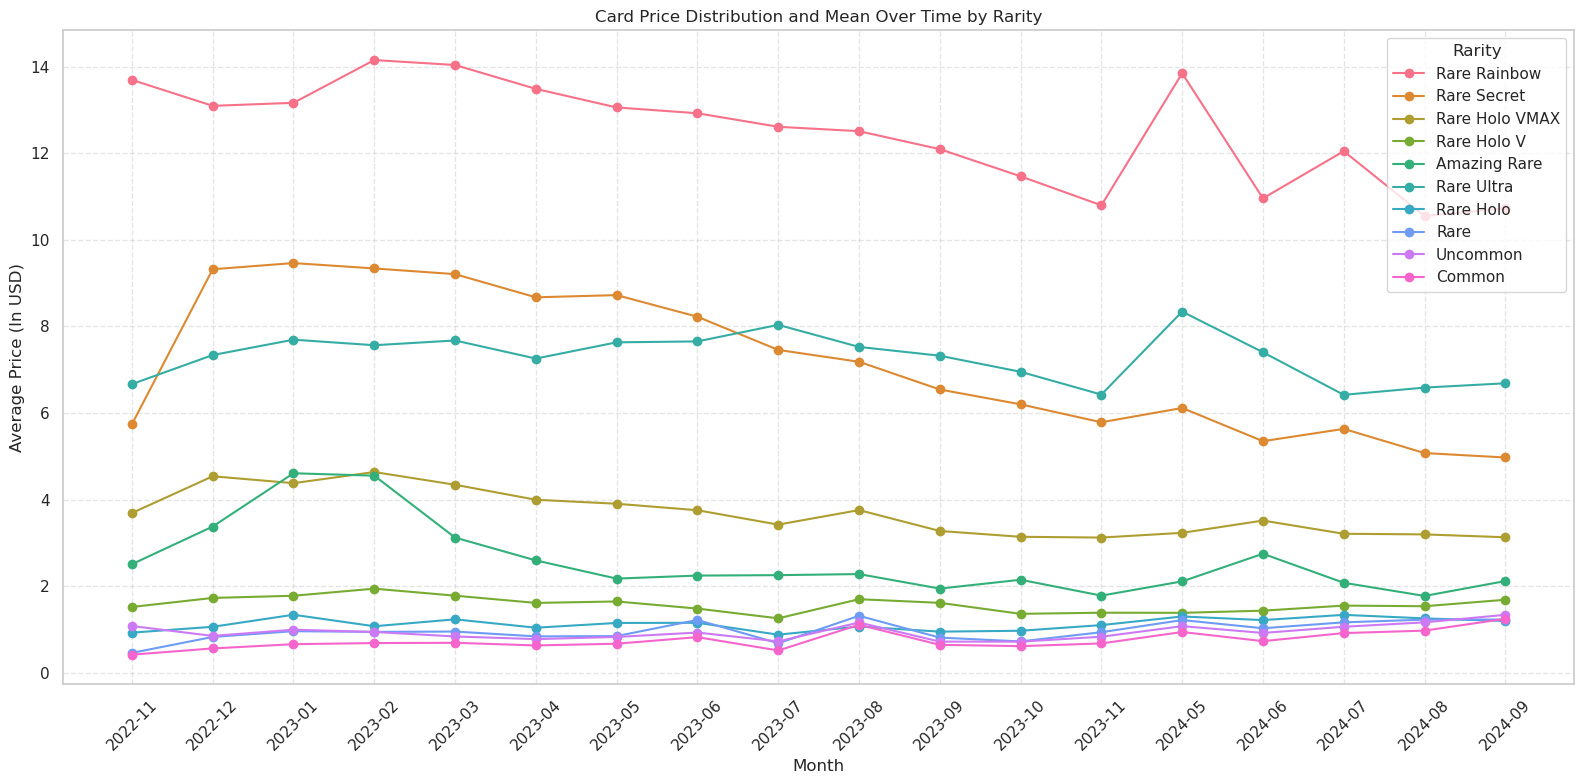

In [10]:
# Graph style
sns.set(style='whitegrid')
plt.figure(figsize=(16, 8))

# Mean line per rarity
palette = sns.color_palette("husl", len(sorted_rarities))
for rarity, color in zip(sorted_rarities, palette):
    subset = df[df['Rarity'] == rarity]
    mean_per_month = subset.groupby('Month')['Average'].mean() / 100
    plt.plot(mean_per_month.index, mean_per_month.values, label=rarity, color=color, marker='o')

# Plot Line Graphs
plt.title('Card Price Distribution and Mean Over Time by Rarity')
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.xticks(rotation=45)
plt.legend(title='Rarity')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


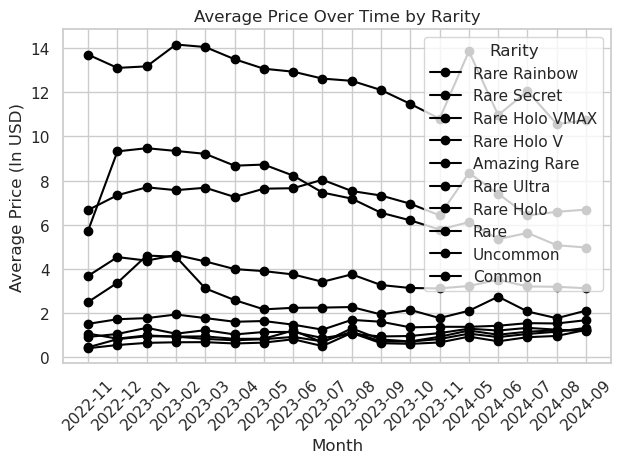

In [11]:
for rarity_df in dfs_by_rarity:
    # print(rarity_df.columns)
    # Find list of months
    months = rarity_df['Month'].unique()
    months = sorted(months)
    # print(months)
    # Iterate over df by month finding the average
    avg_by_month = []
    for month in months:
        month_df = rarity_df[rarity_df['Month'] == month]
        avg_by_month.append(month_df['Average'].mean())

    rarity = rarity_df.iloc[0]['Rarity']
    # lists = sorted(itertools.izip(*[]))
    # plt.figure()
    plt.plot(months, np.array(avg_by_month) / 100, label=rarity, marker='o', c='black')
    plt.title('Average Price Over Time by Rarity')
    plt.xticks(rotation=45)
    plt.xlabel('Month')
    plt.ylabel('Average Price (In USD)')
    plt.legend(title='Rarity')
    plt.grid(True)
    plt.tight_layout()
plt.show()

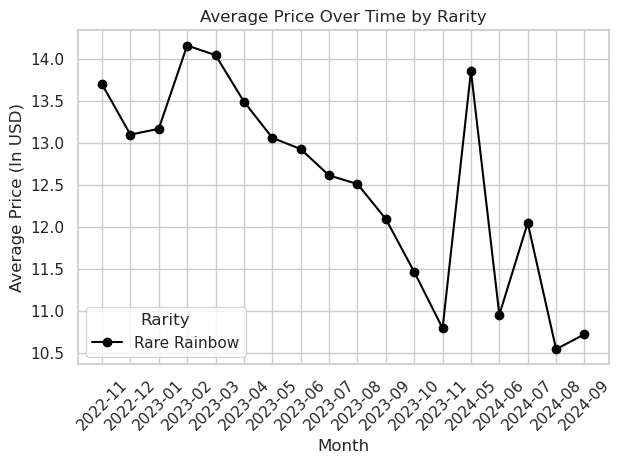

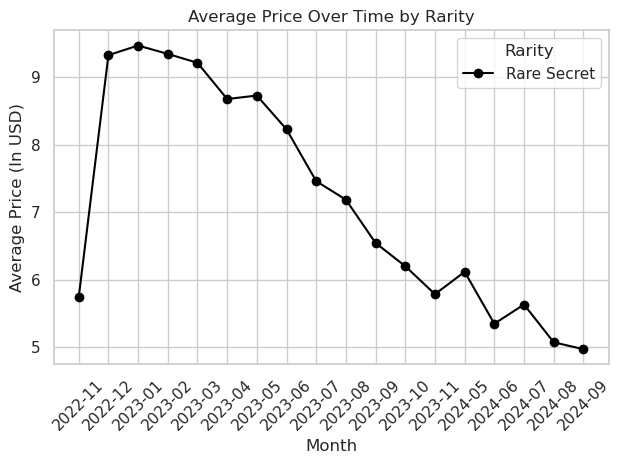

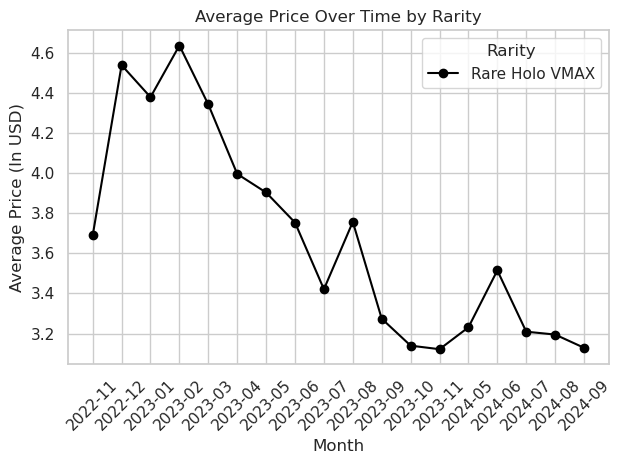

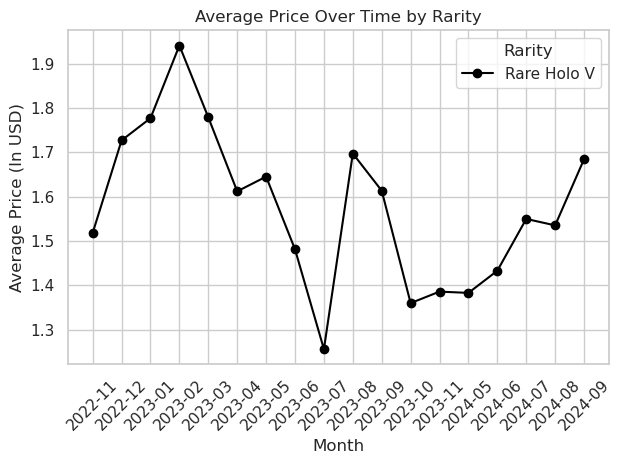

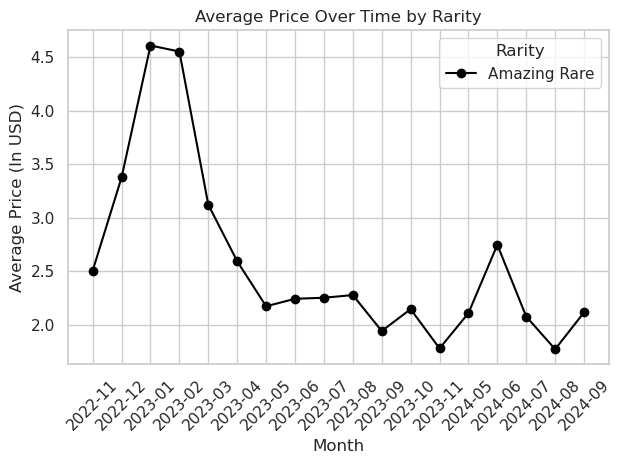

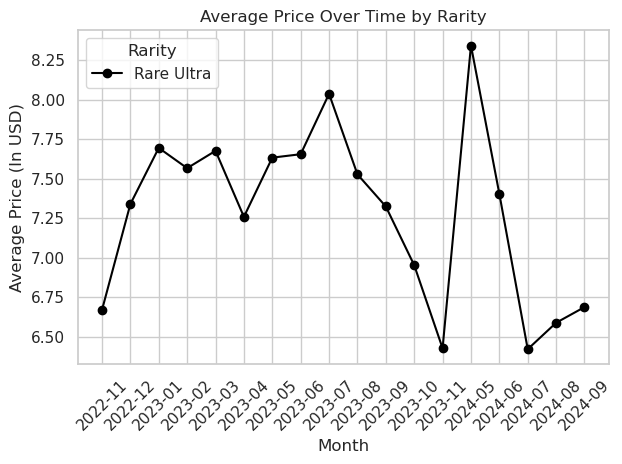

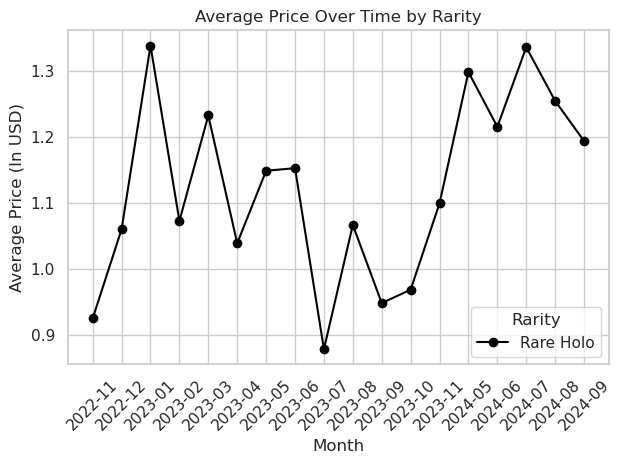

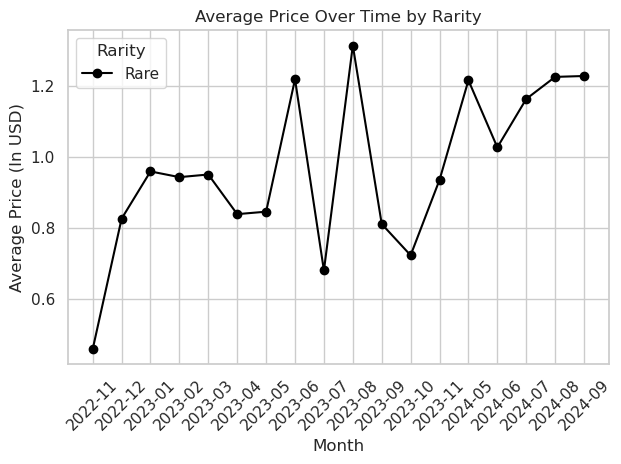

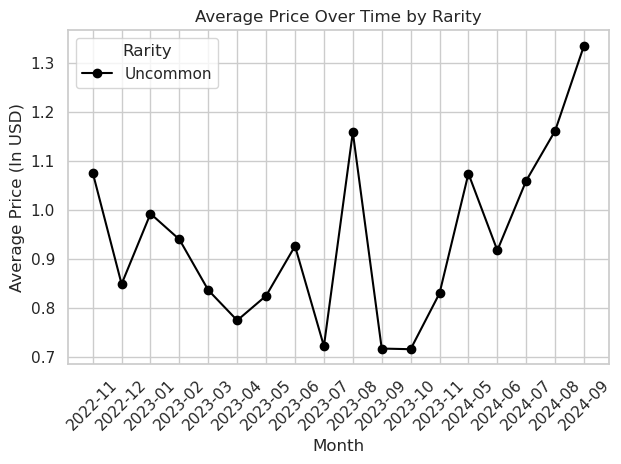

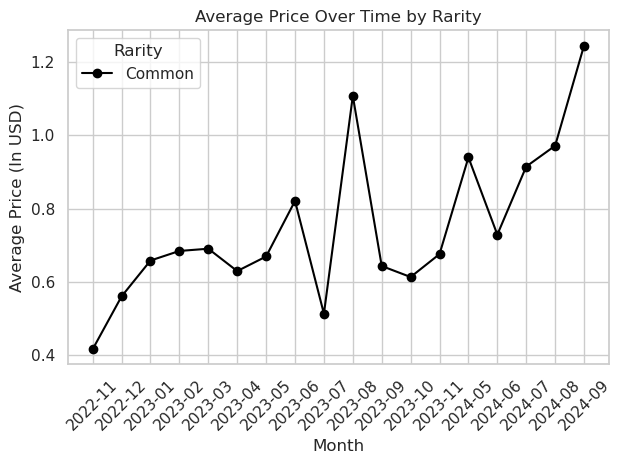

In [12]:
for rarity_df in dfs_by_rarity:
    # print(rarity_df.columns)
    # Find list of months
    months = rarity_df['Month'].unique()
    months = sorted(months)
    # print(months)
    # Iterate over df by month finding the average
    avg_by_month = []
    for month in months:
        month_df = rarity_df[rarity_df['Month'] == month]
        avg_by_month.append(month_df['Average'].mean())

    rarity = rarity_df.iloc[0]['Rarity']
    # lists = sorted(itertools.izip(*[]))
    # plt.figure()
    plt.plot(months, np.array(avg_by_month) / 100, label=rarity, marker='o', c='black')
    plt.title('Average Price Over Time by Rarity')
    plt.xticks(rotation=45)
    plt.xlabel('Month')
    plt.ylabel('Average Price (In USD)')
    plt.legend(title='Rarity')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

**Pyspark Code Below:**

In [36]:
# print(df.head)

#clean the "rarity column"
df_rarity = pd.DataFrame(list(rarityOrder.items()), columns=['Rarity', 'Value'])
df_rarity_sorted = df_rarity.sort_values(by=['Value', 'Rarity']).reset_index(drop=True)
df_rarity_sorted['Rank'] = range(1, len(df_rarity_sorted) + 1)
rarity_to_rank = df_rarity_sorted.set_index('Rarity')['Rank'].to_dict()
df['rarity_rank'] = df['Rarity'].map(rarity_to_rank)

print(sorted(df['rarity_rank'].unique()))
print(df[df['Rarity'] == 'Classic Collection'])

#Create the dataframe we will cluster
cluster_df = df[['rarity_rank', 'Average']].copy()

#Convert to a list of np arrays for spark context
my_tups = list(cluster_df.itertuples(index=False, name=None))
my_tups = [np.array(tup) for tup in my_tups]
# print(my_tups)
# cluster_df.head(20)

[1, 2, 3, 5, 7, 10, 21, 23, 25, 31]
Empty DataFrame
Columns: [Set ID, Number, Name, Rarity, Grade, Month, Average, rarity_rank]
Index: []


In [37]:
#Create spark context
from pyspark import SparkContext

#Cluster our data
from pyspark.mllib.clustering import KMeans
sc = SparkContext.getOrCreate()

#Load our RDD
my_rdd = sc.parallelize(my_tups)
print(len(my_rdd.collect()))

38796


**KMEANS Clustering**

In [38]:
#Detect what an appropriate k-value is
k_vals = []
for i in range(2,11):
    k_vals.append(i)

errors = []
for i in range(2,11):
    K = i
    model = KMeans.train(my_rdd, K, maxIterations=10, initializationMode='random')
    cluster_ids = model.predict(my_rdd)
    errors.append(model.computeCost(my_rdd))

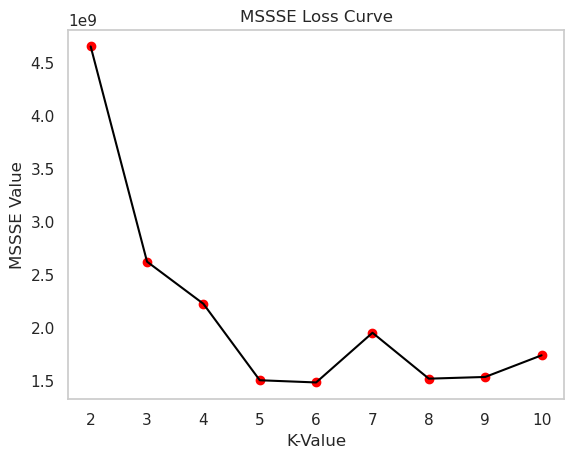

In [39]:
# Plot the WSSSE for different values of k
fig, ax = plt.subplots()
ax.plot(k_vals, errors, c='black')
ax.scatter(k_vals, errors, alpha=1, c='red')
ax.set(xlabel='K-Value',
       ylabel='MSSSE Value',
       title='MSSSE Loss Curve')
ax.grid()

In [40]:
K = 3
model = KMeans.train(my_rdd, K, maxIterations=10, initializationMode='random')
cluster_ids = model.predict(my_rdd)

#Look at out cluster centers:
print(model.clusterCenters)

[array([  4.31720386, 112.0209839 ]), array([  21.43060837, 1085.32386882]), array([  19.53097345, 8245.01044248])]


38796 38796


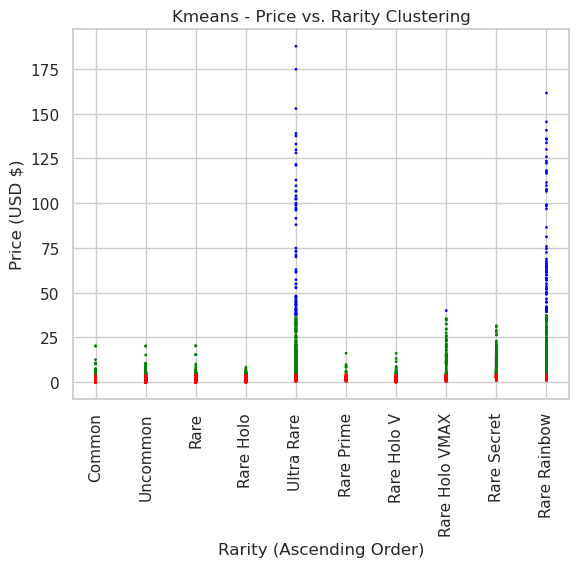

<Figure size 640x480 with 0 Axes>

In [64]:
def plot_clusters(data, cluster_ids, log):
    x_labels = ["Common", "Uncommon", "Rare", "Rare Holo", "Ultra Rare", "Rare Prime", "Rare Holo V", "Rare Holo VMAX", "Rare Secret", "Rare Rainbow"]
    
    #Replace x values with rarity labels
    replace_dict = {1:1, 2:2, 3:3, 5:4, 7:5, 10:6, 21:7, 23:8, 25:9, 31:10}
    data = np.array(data.collect())
    for i in range(0, len(data)):
        data[i][0] = replace_dict[data[i][0]]
        data[i][1] = data[i][1] / 100        
    
    #create custom heatmap for better color visualization ... all the native ones use a difficult color to see.
    colors = ['red', 'green', 'blue']
    my_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
    
    # Define axis labels and plot title
    plt.scatter(data[:,0], data[:,1], c=cluster_ids, s=1, cmap=my_cmap)
    plt.xlabel('Rarity (Ascending Order)')
    plt.ylabel('Price (USD $)')
    plt.title('Kmeans - Price vs. Rarity Clustering')
    if(log):
        plt.yscale('log')
        plt.title('Kmeans - Price vs. Rarity Clustering (Log Scale)')
    xticks = np.unique(data[:,0])
    labels = []
    plt.xticks([1,2,3,4,5,6,7,8,9,10], labels = x_labels, rotation='vertical')
    plt.show()
    plt.clf()
    

def cluster_and_plot(data, K, log):
    # Cluster food items using kMeans and input K value
    K = K
    model = KMeans.train(data, K, maxIterations=10, initializationMode='random')

    # Cluster ID values are used to show clusters with color in plots
    cluster_ids = model.predict(data)
    
    # Plot clusters
    print(len(data.collect()), len(cluster_ids.collect()))
    plot_clusters(data=data, cluster_ids=cluster_ids.collect(), log=log)

#Three clusters -> low, mid, high prices.
cluster_and_plot(data=my_rdd, K=3, log=False)



38796 38796


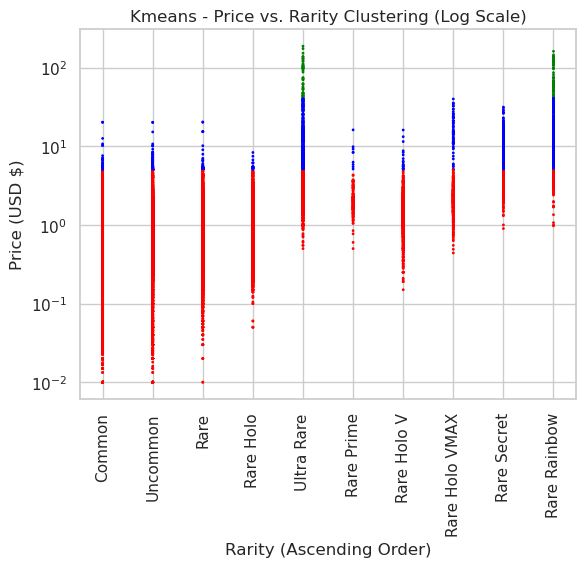

<Figure size 640x480 with 0 Axes>

In [65]:
cluster_and_plot(data=my_rdd, K=3, log=True)

**Outlier Investigation**

In [87]:
#Lets pull the top 5 most expensive cards at each rarity!
#Create our data structure to hold df entries.
rarity_labels = ["Common", 
                 "Uncommon", 
                 "Rare", 
                 "Rare Holo", 
                 "Ultra Rare", 
                 "Rare Prime", 
                 "Rare Holo V", 
                 "Rare Holo VMAX", 
                 "Rare Secret", 
                 "Rare Rainbow"]

expensive_outlier_prices_by_rarity = []
# for i in range(0, len(rarity_labels)):
#     expensive_outlier_prices_by_rarity.append([])

for rarity in rarity_labels:
    filtered_df = df[df['Rarity'] == rarity].sort_values(by="Average", ascending=False)
    print(filtered_df.head(5))
    expensive_outlier_prices_by_rarity.append(filtered_df.head(5))
    

expensive_df = pd.concat(expensive_outlier_prices_by_rarity)
print(expensive_df.sort_values(by='Average', ascending=False))

      Set ID  Number                Name  Rarity             Grade    Month  \
32090  swsh5       1          Bellsprout  Common      reverse-good  2024-08   
24938  swsh4     112     Galarian Meowth  Common      reverse-good  2024-09   
37334  swsh5      66              Mankey  Common  reverse-nearmint  2024-09   
17080  swsh3     112              Nickit  Common   normal-nearmint  2024-07   
824    swsh1     117  Galarian Zigzagoon  Common     normal-played  2024-08   

       Average  rarity_rank  
32090   2025.0            1  
24938   2023.0            1  
37334   1261.0            1  
17080   1074.5            1  
824     1029.0            1  
      Set ID  Number                           Name    Rarity  \
33095  swsh5     121                          Bruno  Uncommon   
11354  swsh2     162                         Nugget  Uncommon   
19966  swsh3     176      Powerful Colorless Energy  Uncommon   
33146  swsh5     122                   Camping Gear  Uncommon   
33674  swsh5     133

**DBSCAN Clustering**

In [19]:
#Frick, dbscan was included in an assignment...
# from src.DBSCAN import DBSCAN

ModuleNotFoundError: No module named 'src'

**KNN**


In [ ]:
#KNN Included in assignment but I need to write it myself.